# Topic 8: Neural Networks with PyTorch

In this notebook we will see how to create some MLP neural networks with **PyTorch**.

The examples are:
- The classical MNIST digits example (multiclass classification with images used as vectors)
- Iris dataset used with 2 ans 3 classes (multiclass and binary classification with tabular data)
- California Housing Dataset (regression)



In [1]:
# install required Python packages
# %pip install torch torchvision matplotlib seaborn scikit-learn -q

In [2]:
# Imports, reproducibility seed, and device selection (CPU/GPU).
import random
import time
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## MINST Example

In [3]:
# Load MNIST and create train/validation/test splits.

# ToTensor rescales pixels to [0,1], Normalize standardizes with MNIST mean/std.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_full = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="data", train=False, download=True, transform=transform)

train_size = 55_000
val_size = len(train_full) - train_size
train_dataset, val_dataset = random_split(
    train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Train samples: 55000
Validation samples: 5000
Test samples: 10000


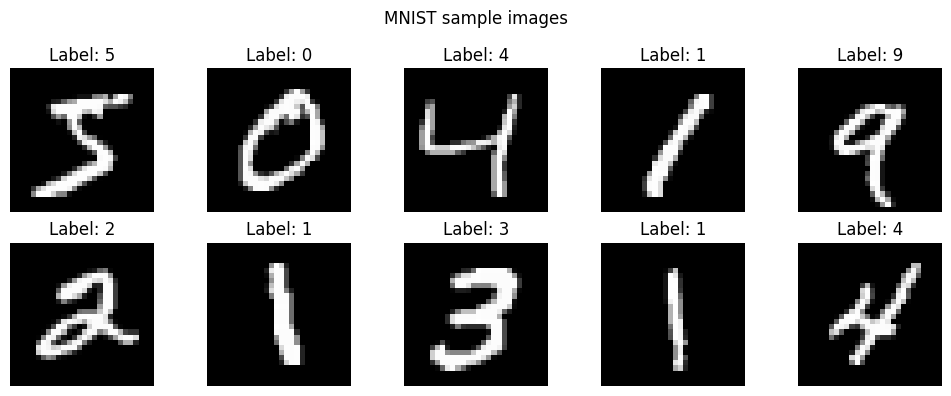

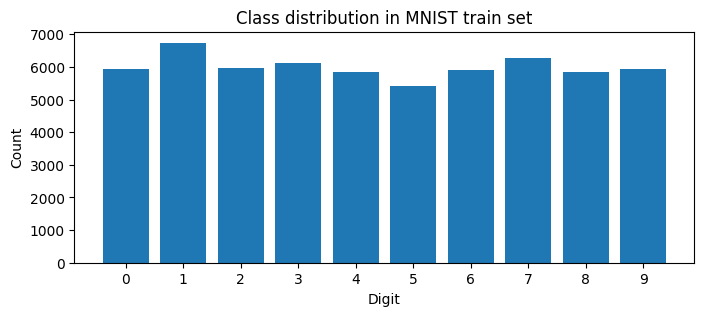

In [4]:
# Visualize sample digits and class distribution.
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flatten()):
    img, label = train_full[i]
    ax.imshow(img.squeeze().numpy(), cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")
plt.suptitle("MNIST sample images")
plt.tight_layout()
plt.show()

counts = torch.bincount(train_full.targets)
plt.figure(figsize=(8, 3))
plt.bar(range(10), counts.numpy())
plt.xticks(range(10))
plt.xlabel("Digit")
plt.ylabel("Count")
plt.title("Class distribution in MNIST train set")
plt.show()

In [5]:
# DataLoader helpers.
def make_loaders(train_ds, val_ds, test_ds, batch_size=128):
    """Create train/validation/test DataLoaders.

    Args:
        train_ds, val_ds, test_ds: datasets for each split.
        batch_size (int): samples per mini-batch.

    Returns:
        tuple: (train_loader, val_loader, test_loader).

    Why shuffle only training:
        random order improves SGD; validation/test stay deterministic.
    """
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(train_dataset, val_dataset, test_dataset, batch_size=128)
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Train batches: 430 | Val batches: 40 | Test batches: 79


In [6]:
# MLP model definition: final layer returns logits; CrossEntropyLoss applies softmax internally.
class MLPClassifier(nn.Module):
    def __init__(self, input_dim=28*28, hidden1=128, hidden2=64, dropout=0.2, num_classes=10):
        """MLP for MNIST classification.

        Args:
            input_dim: flattened image size (28*28=784).
            hidden1, hidden2: hidden layer widths.
            dropout: dropout probability for regularization.
            num_classes: output classes (digits 0-9).
        """
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

model_example = MLPClassifier()
print(model_example)

MLPClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [7]:
# Training/evaluation utilities.
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch.

    Args:
        model: nn.Module to optimize.
        loader: DataLoader with mini-batches (x, y).
        criterion: loss function (e.g., CrossEntropyLoss).
        optimizer: update rule (e.g., Adam).
        device: torch device ('cpu' or 'cuda').

    Returns:
        (avg_loss, accuracy) over the epoch.
    """
    model.train()  # training mode enables dropout behavior
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()  # clear old gradients before backprop
        logits = model(x)  # forward pass -> raw class scores (logits)
        loss = criterion(logits, y)  # compare predictions vs true labels
        loss.backward()  # backprop: compute gradients d(loss)/d(param)
        optimizer.step()  # update parameters using computed gradients

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)  # predicted class = index of highest logit
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate model without gradient tracking.

    Uses model.eval() + torch.no_grad() for deterministic, memory-efficient inference.
    Returns (avg_loss, accuracy).
    """
    model.eval()  # evaluation mode: disable dropout randomness
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)

            total_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return total_loss / total, correct / total


def fit_model(model, train_loader, val_loader, criterion, optimizer, epochs, device):
    """Full training loop across multiple epochs.

    Stores train/val metrics per epoch in `history` for plotting.
    """
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        dt = time.time() - t0
        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f} | {dt:.1f}s"
        )

    return history


def predict_all(model, loader, device):
    """Return NumPy arrays (y_true, y_pred) for sklearn metrics/reporting."""
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            logits = model(x.to(device))
            preds = logits.argmax(dim=1).cpu()
            y_pred.extend(preds.numpy().tolist())
            y_true.extend(y.numpy().tolist())
    return np.array(y_true), np.array(y_pred)


def plot_learning_curves(history, title_prefix="Model"):
    """Plot loss and accuracy curves from `history` dictionary."""
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], marker="o", label="Train")
    plt.plot(epochs, history["val_loss"], marker="o", label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} loss curves")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], marker="o", label="Train")
    plt.plot(epochs, history["val_acc"], marker="o", label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} accuracy curves")
    plt.legend()

    plt.tight_layout()
    plt.show()

def plot_confusion_with_offdiag_highlight(y_true, y_pred, title):
    """Confusion matrix with separate color emphasis for correct vs error cells."""
    cm = confusion_matrix(y_true, y_pred).astype(float)
    n = cm.shape[0]

    diag_mask = np.eye(n, dtype=bool)
    off_diag_mask = ~diag_mask

    diag_vals = np.where(diag_mask, cm, np.nan)
    off_diag_vals = np.where(off_diag_mask, cm, np.nan)

    fig, ax = plt.subplots(figsize=(8, 6))

    # Off-diagonal errors: light-to-strong red scale.
    off_diag_max = np.nanmax(off_diag_vals) if np.any(off_diag_mask) else 0.0
    if np.isfinite(off_diag_max) and off_diag_max > 0:
        sns.heatmap(
            off_diag_vals,
            mask=np.isnan(off_diag_vals),
            cmap=sns.light_palette("#d62728", as_cmap=True),
            vmin=0,
            vmax=off_diag_max,
            cbar=False,
            ax=ax,
            linewidths=0.3,
            linecolor="white",
        )

    # Diagonal correct predictions: light-to-strong blue scale.
    diag_max = np.nanmax(diag_vals) if np.any(diag_mask) else 0.0
    if np.isfinite(diag_max) and diag_max > 0:
        sns.heatmap(
            diag_vals,
            mask=np.isnan(diag_vals),
            cmap=sns.light_palette("#1f77b4", as_cmap=True),
            vmin=0,
            vmax=diag_max,
            cbar=False,
            ax=ax,
            linewidths=0.3,
            linecolor="white",
        )

    # Overlay integer counts.
    for i in range(n):
        for j in range(n):
            ax.text(j + 0.5, i + 0.5, f"{int(cm[i, j])}", ha="center", va="center", color="black", fontsize=9)

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(np.arange(n) + 0.5)
    ax.set_yticks(np.arange(n) + 0.5)
    ax.set_xticklabels(range(n))
    ax.set_yticklabels(range(n), rotation=0)

    ax.text(
        0.0,
        -0.12,
        "Blue scale: diagonal (correct) | Red scale: off-diagonal (errors)",
        transform=ax.transAxes,
        fontsize=9,
        color="dimgray",
    )

    plt.tight_layout()
    plt.show()


In [8]:
# Baseline (first reference model before any hyperparameter tuning) training run.
baseline_cfg = {
    "hidden1": 128,
    "hidden2": 64,
    "dropout": 0.2,
    "lr": 1e-3,
    "epochs": 5,
    "batch_size": 128,
}

train_loader, val_loader, test_loader = make_loaders(
    train_dataset, val_dataset, test_dataset, batch_size=baseline_cfg["batch_size"]
)

baseline_model = MLPClassifier(
    hidden1=baseline_cfg["hidden1"],
    hidden2=baseline_cfg["hidden2"],
    dropout=baseline_cfg["dropout"],
).to(device)

criterion = nn.CrossEntropyLoss()  # multiclass classification loss
optimizer = torch.optim.Adam(baseline_model.parameters(), lr=baseline_cfg["lr"])  # lr controls step size

baseline_history = fit_model(
    baseline_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=baseline_cfg["epochs"],
    device=device,
)

Epoch 01/5 | train_loss=0.3757, train_acc=0.8878 | val_loss=0.1850, val_acc=0.9406 | 24.0s
Epoch 02/5 | train_loss=0.1685, train_acc=0.9489 | val_loss=0.1372, val_acc=0.9594 | 22.7s
Epoch 03/5 | train_loss=0.1241, train_acc=0.9624 | val_loss=0.1203, val_acc=0.9636 | 21.8s
Epoch 04/5 | train_loss=0.1030, train_acc=0.9682 | val_loss=0.1028, val_acc=0.9680 | 30.2s
Epoch 05/5 | train_loss=0.0868, train_acc=0.9727 | val_loss=0.0984, val_acc=0.9728 | 23.0s


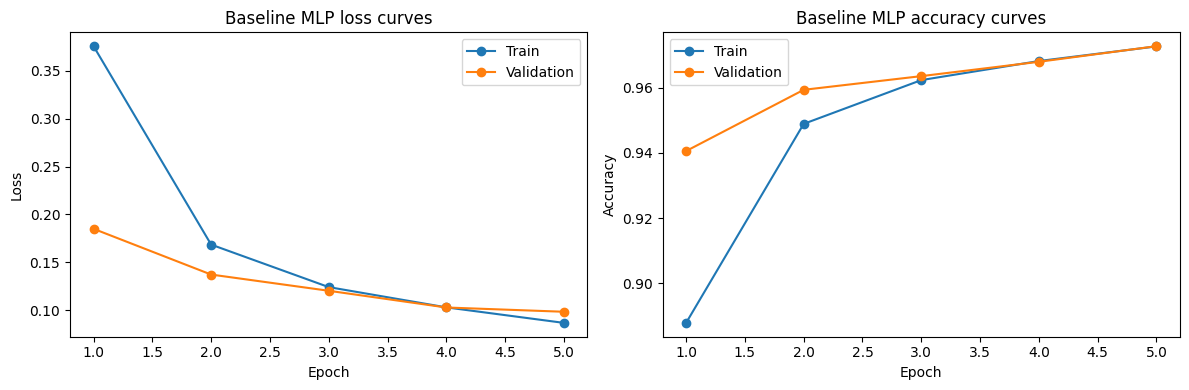

In [9]:
# Plot baseline learning curves.
plot_learning_curves(baseline_history, title_prefix="Baseline MLP")


Baseline test loss: 0.0822
Baseline test accuracy: 0.9742


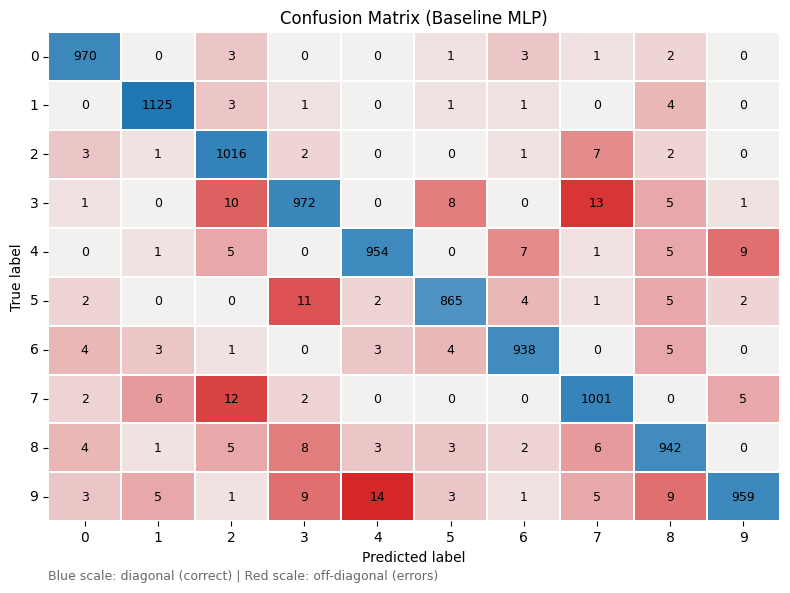

              precision    recall  f1-score   support

           0     0.9808    0.9898    0.9853       980
           1     0.9851    0.9912    0.9881      1135
           2     0.9621    0.9845    0.9732      1032
           3     0.9672    0.9624    0.9648      1010
           4     0.9775    0.9715    0.9745       982
           5     0.9774    0.9697    0.9736       892
           6     0.9801    0.9791    0.9796       958
           7     0.9671    0.9737    0.9704      1028
           8     0.9622    0.9671    0.9647       974
           9     0.9826    0.9504    0.9662      1009

    accuracy                         0.9742     10000
   macro avg     0.9742    0.9740    0.9740     10000
weighted avg     0.9743    0.9742    0.9742     10000



In [10]:
# Baseline test metrics: accuracy, confusion matrix, and classification report.
test_loss, test_acc = evaluate(baseline_model, test_loader, criterion, device)
print(f"Baseline test loss: {test_loss:.4f}")
print(f"Baseline test accuracy: {test_acc:.4f}")

y_true, y_pred = predict_all(baseline_model, test_loader, device)
plot_confusion_with_offdiag_highlight(
    y_true,
    y_pred,
    title="Confusion Matrix (Baseline MLP)",
)

print(classification_report(y_true, y_pred, digits=4))


**Hyperparameter tuning**

We now run a small search over hidden size and learning rate.
To keep runtime low in the example, we train each candidate for a few epochs on a reduced train subset.

In [11]:
# 9) Mini tuning setup.
subset_size = 12_000
subset_indices = torch.randperm(len(train_dataset), generator=torch.Generator().manual_seed(seed))[:subset_size]
train_tune_subset = Subset(train_dataset, subset_indices.tolist())


def run_experiment(cfg, epochs=2):
    """Train one config from the tuning grid.

    Args:
        cfg: dict with hidden sizes, dropout, learning rate, batch size.
        epochs: short runs for fast classroom comparison.

    Returns:
        dict with config, best validation accuracy, and training history.
    """
    train_loader_t, val_loader_t, _ = make_loaders(
        train_tune_subset,
        val_dataset,
        test_dataset,
        batch_size=cfg["batch_size"],
    )

    model = MLPClassifier(
        hidden1=cfg["hidden1"],
        hidden2=cfg["hidden2"],
        dropout=cfg["dropout"],
    ).to(device)

    criterion = nn.CrossEntropyLoss()  # same objective for fair config comparison
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"])  # each config can use a different lr

    history = fit_model(model, train_loader_t, val_loader_t, criterion, optimizer, epochs=epochs, device=device)
    best_val_acc = max(history["val_acc"])

    return {
        "config": cfg,
        "best_val_acc": best_val_acc,
        "history": history,
    }

In [12]:
# Grid search loops through candidate hyperparameters and ranks them by best validation accuracy.
grid = [
    {"hidden1": 128, "hidden2": 64,  "dropout": 0.2, "lr": 1e-3, "batch_size": 128},
    {"hidden1": 128, "hidden2": 64,  "dropout": 0.2, "lr": 3e-4, "batch_size": 128},
    {"hidden1": 256, "hidden2": 128, "dropout": 0.2, "lr": 1e-3, "batch_size": 128},
    {"hidden1": 256, "hidden2": 128, "dropout": 0.2, "lr": 3e-4, "batch_size": 128},
]

results = []
for i, cfg in enumerate(grid, start=1):
    print("=" * 70)
    print(f"Tuning run {i}/{len(grid)} | cfg={cfg}")
    result = run_experiment(cfg, epochs=2)
    results.append(result)

results = sorted(results, key=lambda r: r["best_val_acc"], reverse=True)

print("\nRanked tuning results:")
for rank, r in enumerate(results, start=1):
    cfg = r["config"]
    print(
        f"{rank}. val_acc={r['best_val_acc']:.4f} | "
        f"hidden=({cfg['hidden1']},{cfg['hidden2']}), "
        f"lr={cfg['lr']}, dropout={cfg['dropout']}"
    )

best_cfg = results[0]["config"]
print(f"\nBest config selected: {best_cfg}")

Tuning run 1/4 | cfg={'hidden1': 128, 'hidden2': 64, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 128}
Epoch 01/2 | train_loss=0.7380, train_acc=0.7781 | val_loss=0.3481, val_acc=0.8968 | 5.9s
Epoch 02/2 | train_loss=0.3176, train_acc=0.9052 | val_loss=0.2805, val_acc=0.9146 | 5.7s
Tuning run 2/4 | cfg={'hidden1': 128, 'hidden2': 64, 'dropout': 0.2, 'lr': 0.0003, 'batch_size': 128}
Epoch 01/2 | train_loss=1.2885, train_acc=0.6606 | val_loss=0.5644, val_acc=0.8470 | 5.7s
Epoch 02/2 | train_loss=0.4723, train_acc=0.8658 | val_loss=0.3839, val_acc=0.8862 | 5.1s
Tuning run 3/4 | cfg={'hidden1': 256, 'hidden2': 128, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 128}
Epoch 01/2 | train_loss=0.6119, train_acc=0.8160 | val_loss=0.3076, val_acc=0.9088 | 5.7s
Epoch 02/2 | train_loss=0.2476, train_acc=0.9238 | val_loss=0.2457, val_acc=0.9230 | 4.9s
Tuning run 4/4 | cfg={'hidden1': 256, 'hidden2': 128, 'dropout': 0.2, 'lr': 0.0003, 'batch_size': 128}
Epoch 01/2 | train_loss=1.0000, train_acc=0.7445 | v

Epoch 01/3 | train_loss=0.3041, train_acc=0.9077 | val_loss=0.1489, val_acc=0.9544 | 17.2s
Epoch 02/3 | train_loss=0.1298, train_acc=0.9601 | val_loss=0.0986, val_acc=0.9672 | 14.2s
Epoch 03/3 | train_loss=0.0942, train_acc=0.9705 | val_loss=0.0893, val_acc=0.9734 | 14.0s
Best-config test loss: 0.0799
Best-config test accuracy: 0.9750
Baseline test accuracy: 0.9742


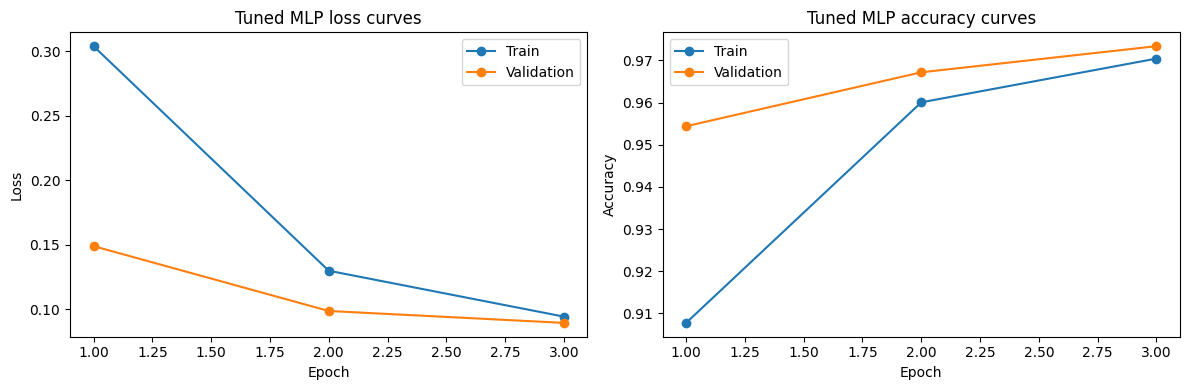

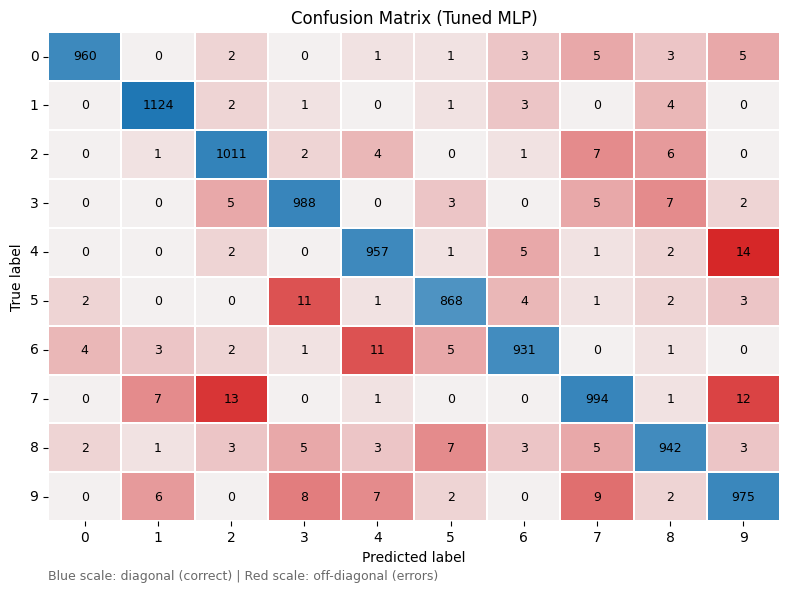

              precision    recall  f1-score   support

           0     0.9917    0.9796    0.9856       980
           1     0.9842    0.9903    0.9873      1135
           2     0.9721    0.9797    0.9759      1032
           3     0.9724    0.9782    0.9753      1010
           4     0.9716    0.9745    0.9731       982
           5     0.9775    0.9731    0.9753       892
           6     0.9800    0.9718    0.9759       958
           7     0.9679    0.9669    0.9674      1028
           8     0.9711    0.9671    0.9691       974
           9     0.9615    0.9663    0.9639      1009

    accuracy                         0.9750     10000
   macro avg     0.9750    0.9748    0.9749     10000
weighted avg     0.9750    0.9750    0.9750     10000



In [13]:
# Retrain best hyperparameters on full training split for fair final comparison.
best_model = MLPClassifier(
    hidden1=best_cfg["hidden1"],
    hidden2=best_cfg["hidden2"],
    dropout=best_cfg["dropout"],
).to(device)

criterion = nn.CrossEntropyLoss()  # same loss as baseline
optimizer = torch.optim.Adam(best_model.parameters(), lr=best_cfg["lr"])  # best learning rate from tuning

train_loader, val_loader, test_loader = make_loaders(
    train_dataset, val_dataset, test_dataset, batch_size=best_cfg["batch_size"]
)

best_history = fit_model(
    best_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=3,
    device=device,
)

best_test_loss, best_test_acc = evaluate(best_model, test_loader, criterion, device)
print(f"Best-config test loss: {best_test_loss:.4f}")
print(f"Best-config test accuracy: {best_test_acc:.4f}")
print(f"Baseline test accuracy: {test_acc:.4f}")

plot_learning_curves(best_history, title_prefix="Tuned MLP")

best_y_true, best_y_pred = predict_all(best_model, test_loader, device)
plot_confusion_with_offdiag_highlight(
    best_y_true,
    best_y_pred,
    title="Confusion Matrix (Tuned MLP)",
)

print(classification_report(best_y_true, best_y_pred, digits=4))


## Iris Dataset


In [14]:
# Iris tabular setup and reusable helpers.
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset
from matplotlib.colors import ListedColormap


def build_tabular_loaders(X, y, batch_size=16, test_size=0.2, val_size=0.2, seed=42):
    """Create loaders for tabular classification.

    Args:
        X, y: features and labels.
        batch_size: samples per mini-batch.
        test_size: fraction reserved for test split.
        val_size: fraction reserved for validation from train split.
        seed: random state for reproducible splits.

    Returns:
        train_loader, val_loader, test_loader, scaler
    """
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=seed
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=val_size, stratify=y_train_full, random_state=seed
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    train_ds = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long),
    )
    val_ds = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.long),
    )
    test_ds = TensorDataset(
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.long),
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader, scaler


class TabularNN(nn.Module):
    def __init__(self, input_dim, num_classes, hidden1=32, hidden2=16, dropout=0.1):
        """Small MLP for tabular classification.

        Args:
            input_dim: number of input features.
            num_classes: number of class labels.
            hidden1, hidden2: hidden layer sizes.
            dropout: dropout probability.
        """
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, num_classes),
        )

    def forward(self, x):
        return self.net(x)


def train_tabular_classifier(
    train_loader,
    val_loader,
    input_dim,
    num_classes,
    epochs=60,
    lr=5e-3,
    hidden1=32,
    hidden2=16,
    dropout=0.1,
):
    """Train TabularNN and return (model, history, criterion).

    Main knobs: epochs, lr, hidden sizes, dropout.
    """
    model = TabularNN(
        input_dim=input_dim,
        num_classes=num_classes,
        hidden1=hidden1,
        hidden2=hidden2,
        dropout=dropout,
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = fit_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        epochs=epochs,
        device=device,
    )

    return model, history, criterion


def plot_decision_boundary_2d(
    model,
    X_raw_2d,
    y,
    scaler,
    class_names,
    title,
    feature_names=("petal length (cm)", "petal width (cm)"),
    h=0.02,
):
    """Plot model decision regions on a 2D feature grid.

    `h` controls grid resolution: lower values are smoother but slower.
    """
    x_min, x_max = X_raw_2d[:, 0].min() - 0.5, X_raw_2d[:, 0].max() + 0.5
    y_min, y_max = X_raw_2d[:, 1].min() - 0.5, X_raw_2d[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h),
    )

    grid_raw = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid_raw)

    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(grid_scaled, dtype=torch.float32, device=device))
        z = logits.argmax(dim=1).cpu().numpy().reshape(xx.shape)

    n_classes = len(class_names)
    cmap_light = ListedColormap(sns.color_palette("pastel", n_classes).as_hex())
    cmap_bold = ListedColormap(sns.color_palette("deep", n_classes).as_hex())

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, z, alpha=0.35, cmap=cmap_light)
    plt.contour(
        xx,
        yy,
        z,
        levels=np.arange(-0.5, n_classes, 1),
        colors="k",
        linewidths=0.5,
        alpha=0.5,
    )

    for class_idx, class_name in enumerate(class_names):
        mask = y == class_idx
        plt.scatter(
            X_raw_2d[mask, 0],
            X_raw_2d[mask, 1],
            c=[cmap_bold(class_idx)],
            edgecolor="k",
            s=55,
            label=class_name,
        )

    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title(title)
    plt.legend(title="Class")
    plt.tight_layout()
    plt.show()


### A) Iris multiclass
We predict the original 3 Iris classes with a small feedforward NN, using only **petal length** and **petal width** so we can visualize 2D decision boundaries.


Epoch 01/40 | train_loss=0.8726, train_acc=0.7188 | val_loss=0.7373, val_acc=0.7083 | 0.0s
Epoch 02/40 | train_loss=0.6599, train_acc=0.6771 | val_loss=0.5696, val_acc=0.6667 | 0.0s
Epoch 03/40 | train_loss=0.5155, train_acc=0.7396 | val_loss=0.5057, val_acc=0.7083 | 0.0s
Epoch 04/40 | train_loss=0.4289, train_acc=0.8229 | val_loss=0.4524, val_acc=0.7083 | 0.0s
Epoch 05/40 | train_loss=0.3624, train_acc=0.8646 | val_loss=0.3912, val_acc=0.7500 | 0.0s
Epoch 06/40 | train_loss=0.3254, train_acc=0.9062 | val_loss=0.3324, val_acc=0.8750 | 0.0s
Epoch 07/40 | train_loss=0.2584, train_acc=0.9792 | val_loss=0.2838, val_acc=0.8750 | 0.0s
Epoch 08/40 | train_loss=0.2004, train_acc=0.9896 | val_loss=0.2255, val_acc=0.9583 | 0.0s
Epoch 09/40 | train_loss=0.1727, train_acc=0.9583 | val_loss=0.2194, val_acc=0.9167 | 0.0s
Epoch 10/40 | train_loss=0.1450, train_acc=0.9583 | val_loss=0.1719, val_acc=0.9583 | 0.0s
Epoch 11/40 | train_loss=0.1069, train_acc=0.9688 | val_loss=0.1638, val_acc=0.9583 | 0.0s

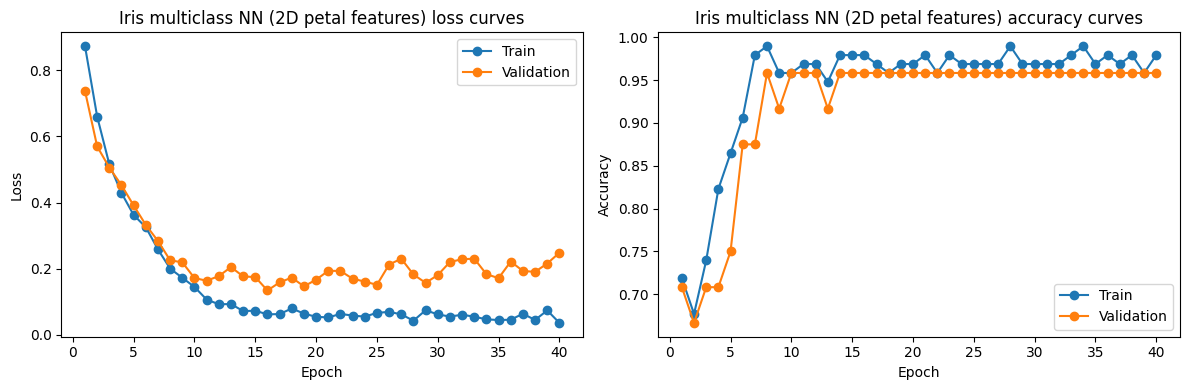

Iris multiclass test loss: 0.1885
Iris multiclass test accuracy: 0.9333


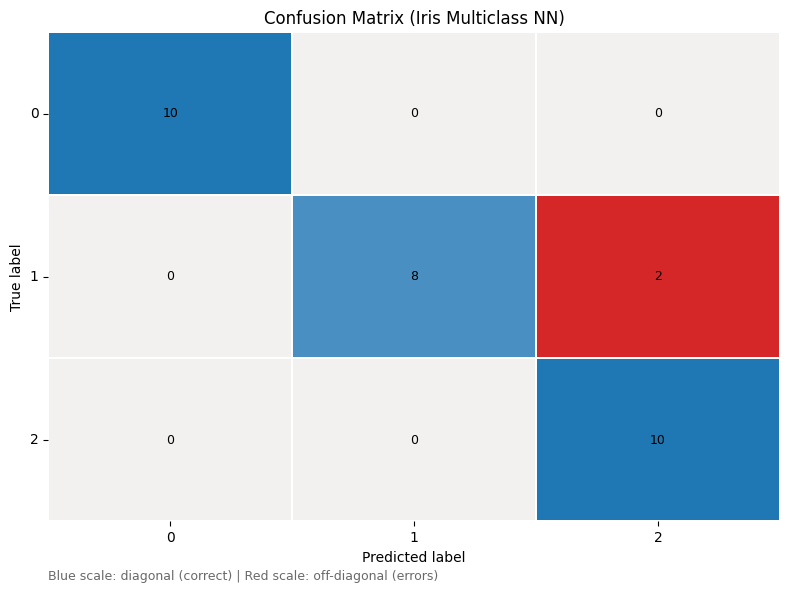

              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     1.0000    0.8000    0.8889        10
   virginica     0.8333    1.0000    0.9091        10

    accuracy                         0.9333        30
   macro avg     0.9444    0.9333    0.9327        30
weighted avg     0.9444    0.9333    0.9327        30



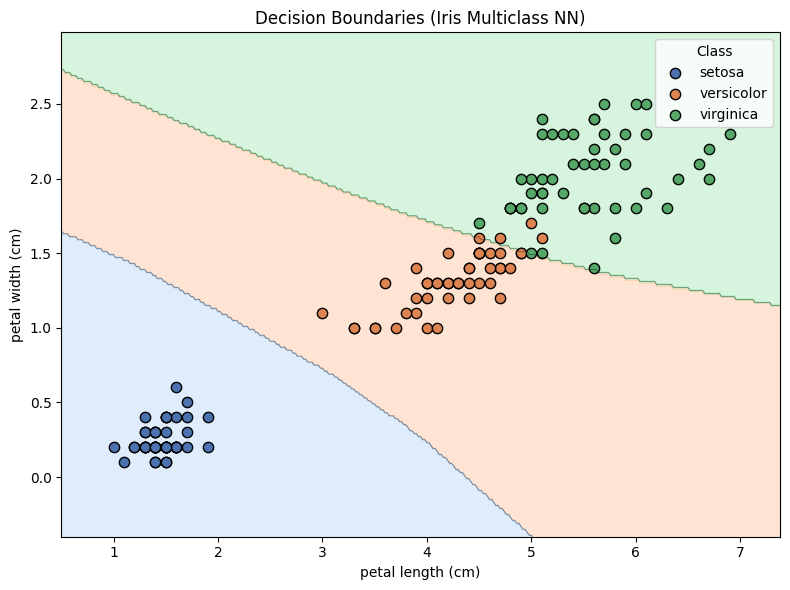

In [15]:
# Train/evaluate NN on Iris multiclass classification (2D petal features).
iris = load_iris()
feature_idx = [2, 3]  # petal length, petal width
feature_names = [iris.feature_names[i] for i in feature_idx]

X_iris_2d = iris.data[:, feature_idx]
y_iris = iris.target

train_loader_iris, val_loader_iris, test_loader_iris, scaler_iris = build_tabular_loaders(
    X_iris_2d, y_iris, batch_size=16, test_size=0.2, val_size=0.2, seed=42
)

iris_multi_model, iris_multi_history, iris_multi_criterion = train_tabular_classifier(
    train_loader_iris,
    val_loader_iris,
    input_dim=X_iris_2d.shape[1],
    num_classes=3,
    epochs=40,
    lr=5e-3,
    hidden1=32,
    hidden2=16,
    dropout=0.1,
)

plot_learning_curves(iris_multi_history, title_prefix="Iris multiclass NN (2D petal features)")

iris_multi_test_loss, iris_multi_test_acc = evaluate(
    iris_multi_model, test_loader_iris, iris_multi_criterion, device
)
print(f"Iris multiclass test loss: {iris_multi_test_loss:.4f}")
print(f"Iris multiclass test accuracy: {iris_multi_test_acc:.4f}")

y_true_iris_multi, y_pred_iris_multi = predict_all(iris_multi_model, test_loader_iris, device)
plot_confusion_with_offdiag_highlight(
    y_true_iris_multi,
    y_pred_iris_multi,
    title="Confusion Matrix (Iris Multiclass NN)",
)
print(classification_report(
    y_true_iris_multi,
    y_pred_iris_multi,
    target_names=iris.target_names,
    digits=4,
))

plot_decision_boundary_2d(
    iris_multi_model,
    X_iris_2d,
    y_iris,
    scaler_iris,
    class_names=list(iris.target_names),
    title="Decision Boundaries (Iris Multiclass NN)",
    feature_names=feature_names,
)


### B) Iris binary (2 classes merged)

Now we merge **setosa** and **virginica** into one class:

- `0` = setosa or virginica
- `1` = versicolor



Epoch 01/40 | train_loss=0.6605, train_acc=0.6250 | val_loss=0.5673, val_acc=0.6667 | 0.0s
Epoch 02/40 | train_loss=0.5467, train_acc=0.6771 | val_loss=0.4856, val_acc=0.6667 | 0.0s
Epoch 03/40 | train_loss=0.4693, train_acc=0.6667 | val_loss=0.4307, val_acc=0.6667 | 0.0s
Epoch 04/40 | train_loss=0.4218, train_acc=0.6667 | val_loss=0.3790, val_acc=0.6667 | 0.0s
Epoch 05/40 | train_loss=0.3726, train_acc=0.7500 | val_loss=0.3205, val_acc=0.9167 | 0.0s
Epoch 06/40 | train_loss=0.3266, train_acc=0.9062 | val_loss=0.2628, val_acc=0.9583 | 0.0s
Epoch 07/40 | train_loss=0.2775, train_acc=0.9375 | val_loss=0.2070, val_acc=1.0000 | 0.0s
Epoch 08/40 | train_loss=0.2451, train_acc=0.9375 | val_loss=0.1615, val_acc=1.0000 | 0.0s
Epoch 09/40 | train_loss=0.1949, train_acc=0.9688 | val_loss=0.1281, val_acc=1.0000 | 0.0s
Epoch 10/40 | train_loss=0.1776, train_acc=0.9583 | val_loss=0.0998, val_acc=1.0000 | 0.0s
Epoch 11/40 | train_loss=0.1640, train_acc=0.9375 | val_loss=0.0814, val_acc=1.0000 | 0.0s

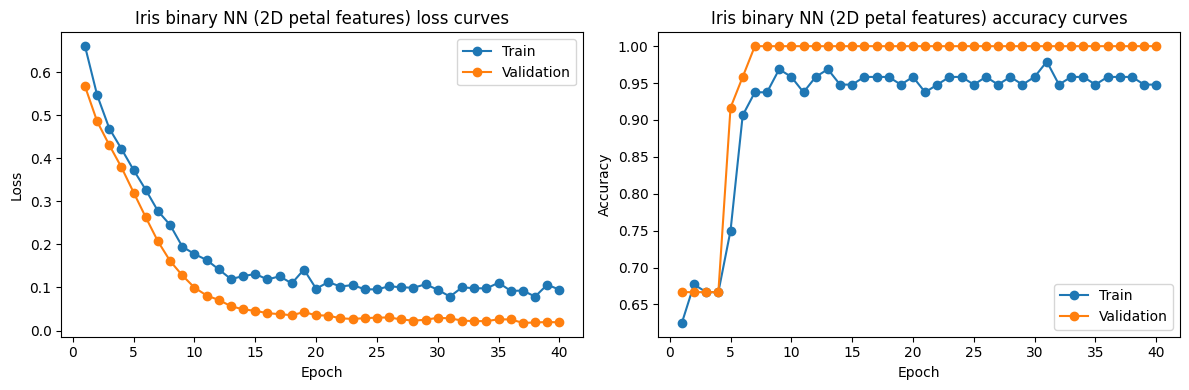

Iris binary test loss: 0.0851
Iris binary test accuracy: 0.9667


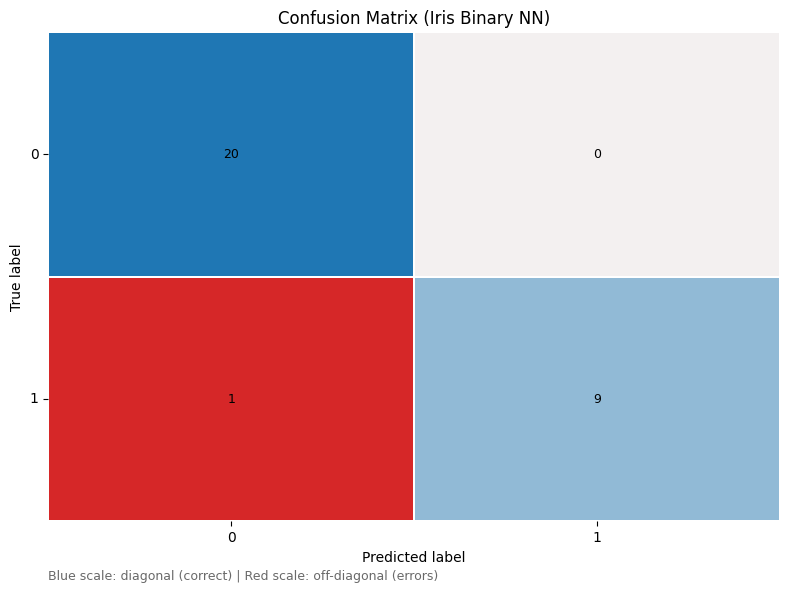

                     precision    recall  f1-score   support

setosa_or_virginica     0.9524    1.0000    0.9756        20
         versicolor     1.0000    0.9000    0.9474        10

           accuracy                         0.9667        30
          macro avg     0.9762    0.9500    0.9615        30
       weighted avg     0.9683    0.9667    0.9662        30



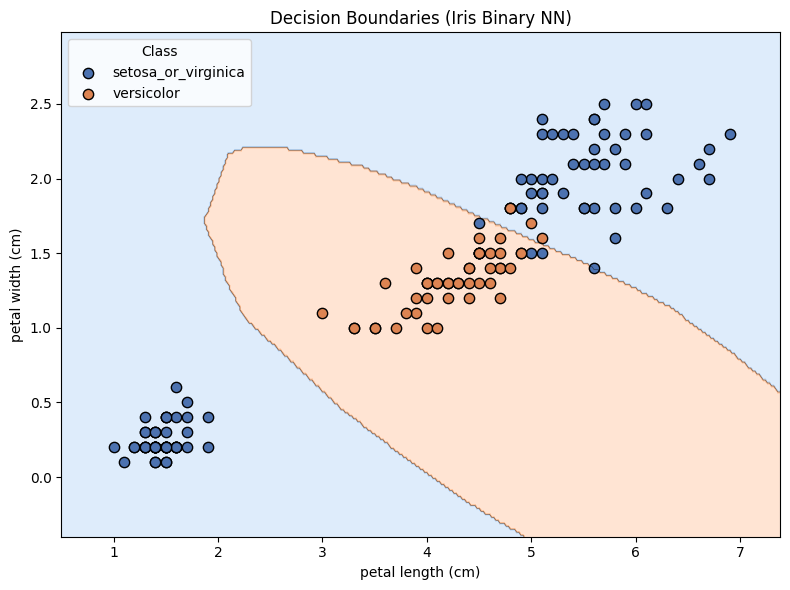

In [16]:
# Train/evaluate NN on Iris binary classification (setosa+virginica merged).
y_iris_binary = np.where(y_iris == 1, 1, 0)

train_loader_iris_bin, val_loader_iris_bin, test_loader_iris_bin, scaler_iris_bin = build_tabular_loaders(
    X_iris_2d, y_iris_binary, batch_size=16, test_size=0.2, val_size=0.2, seed=42
)

iris_bin_model, iris_bin_history, iris_bin_criterion = train_tabular_classifier(
    train_loader_iris_bin,
    val_loader_iris_bin,
    input_dim=X_iris_2d.shape[1],
    num_classes=2,
    epochs=40,
    lr=5e-3,
    hidden1=32,
    hidden2=16,
    dropout=0.1,
)

plot_learning_curves(iris_bin_history, title_prefix="Iris binary NN (2D petal features)")

iris_bin_test_loss, iris_bin_test_acc = evaluate(
    iris_bin_model, test_loader_iris_bin, iris_bin_criterion, device
)
print(f"Iris binary test loss: {iris_bin_test_loss:.4f}")
print(f"Iris binary test accuracy: {iris_bin_test_acc:.4f}")

y_true_iris_bin, y_pred_iris_bin = predict_all(iris_bin_model, test_loader_iris_bin, device)
plot_confusion_with_offdiag_highlight(
    y_true_iris_bin,
    y_pred_iris_bin,
    title="Confusion Matrix (Iris Binary NN)",
)
print(classification_report(
    y_true_iris_bin,
    y_pred_iris_bin,
    target_names=["setosa_or_virginica", "versicolor"],
    digits=4,
))

plot_decision_boundary_2d(
    iris_bin_model,
    X_iris_2d,
    y_iris_binary,
    scaler_iris_bin,
    class_names=["setosa_or_virginica", "versicolor"],
    title="Decision Boundaries (Iris Binary NN)",
    feature_names=feature_names,
)


## California Housing Dataset

Now we switch to a **regression** task using the **California Housing** dataset (median house value prediction)

In [17]:
# California Housing regression setup and PyTorch helpers.
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset


def build_regression_loaders(X, y, batch_size=128, test_size=0.2, val_size=0.2, seed=42):
    """Create train/val/test loaders for regression.

    Also returns x/y scalers so predictions can be inverted to original units.
    """
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=test_size, random_state=seed
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=val_size, random_state=seed
    )

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train = x_scaler.fit_transform(X_train)
    X_val = x_scaler.transform(X_val)
    X_test = x_scaler.transform(X_test)

    y_train = y_scaler.fit_transform(y_train.reshape(-1, 1))
    y_val = y_scaler.transform(y_val.reshape(-1, 1))
    y_test = y_scaler.transform(y_test.reshape(-1, 1))

    train_ds = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32),
    )
    val_ds = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32),
    )
    test_ds = TensorDataset(
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.float32),
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader, x_scaler, y_scaler


class HousingRegressor(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=32, dropout=0.1):
        """MLP regressor with one scalar output."""
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 1),
        )

    def forward(self, x):
        return self.net(x)


def train_one_epoch_reg(model, loader, criterion, optimizer, device):
    """One optimization epoch for regression; returns average loss."""
    model.train()
    total_loss, total = 0.0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total += x.size(0)

    return total_loss / total


def evaluate_reg_loss(model, loader, criterion, device):
    """Validation/test regression loss with no gradient tracking."""
    model.eval()
    total_loss, total = 0.0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            loss = criterion(pred, y)
            total_loss += loss.item() * x.size(0)
            total += x.size(0)

    return total_loss / total


def fit_regressor(model, train_loader, val_loader, criterion, optimizer, epochs, device):
    """Train regressor for multiple epochs and store train/val loss history."""
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch_reg(model, train_loader, criterion, optimizer, device)
        val_loss = evaluate_reg_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            print(f"Epoch {epoch:03d}/{epochs} | train_mse={train_loss:.4f} | val_mse={val_loss:.4f}")

    return history


def predict_regression(model, loader, device):
    """Collect true and predicted targets from a loader (still in scaled space)."""
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            pred = model(x).cpu().numpy()
            y_pred.append(pred)
            y_true.append(y.numpy())

    y_true = np.vstack(y_true)
    y_pred = np.vstack(y_pred)
    return y_true, y_pred

Epoch 001/50 | train_mse=0.6084 | val_mse=0.4366
Epoch 010/50 | train_mse=0.2735 | val_mse=0.4184
Epoch 020/50 | train_mse=0.2412 | val_mse=0.2557
Epoch 030/50 | train_mse=0.2239 | val_mse=0.2363
Epoch 040/50 | train_mse=0.2153 | val_mse=0.2234
Epoch 050/50 | train_mse=0.2120 | val_mse=0.2230


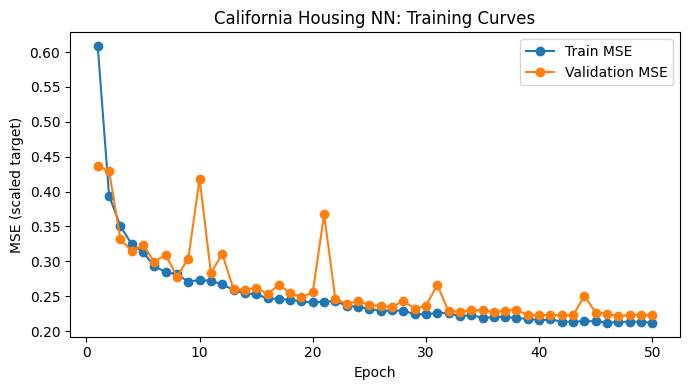

California Housing test MAE:  0.3542
California Housing test RMSE: 0.5329
California Housing test R^2:   0.7833


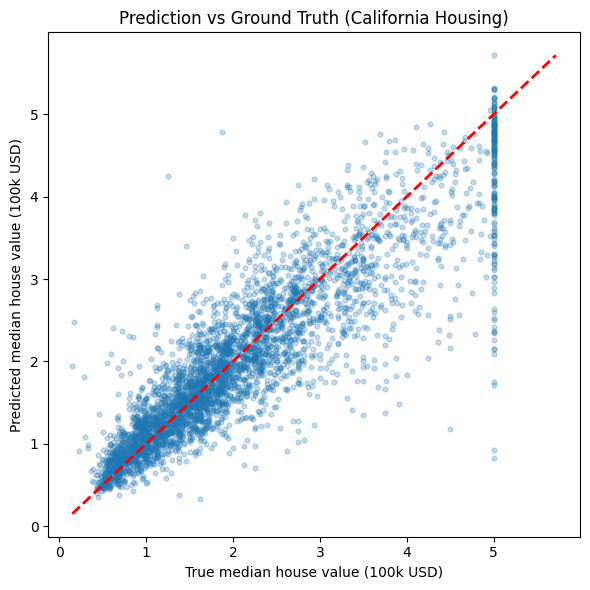

In [18]:
# Train/evaluate NN regressor on California Housing.
cal_housing = fetch_california_housing(as_frame=True)
X_house = cal_housing.data.values
y_house = cal_housing.target.values

train_loader_house, val_loader_house, test_loader_house, x_scaler_house, y_scaler_house = build_regression_loaders(
    X_house, y_house, batch_size=128, test_size=0.2, val_size=0.2, seed=42
)

house_model = HousingRegressor(
    input_dim=X_house.shape[1],
    hidden1=64,
    hidden2=32,
    dropout=0.1,
).to(device)

criterion_house = nn.MSELoss()  # penalizes squared prediction errors
optimizer_house = torch.optim.Adam(house_model.parameters(), lr=1e-3)

house_history = fit_regressor(
    house_model,
    train_loader_house,
    val_loader_house,
    criterion_house,
    optimizer_house,
    epochs=50,
    device=device,
)

# Plot training curves (MSE on standardized target).
epochs = range(1, len(house_history["train_loss"]) + 1)
plt.figure(figsize=(7, 4))
plt.plot(epochs, house_history["train_loss"], marker="o", label="Train MSE")
plt.plot(epochs, house_history["val_loss"], marker="o", label="Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE (scaled target)")
plt.title("California Housing NN: Training Curves")
plt.legend()
plt.tight_layout()
plt.show()

# Evaluate on test set in original target units.
y_true_scaled, y_pred_scaled = predict_regression(house_model, test_loader_house, device)
y_true = y_scaler_house.inverse_transform(y_true_scaled).ravel()
y_pred = y_scaler_house.inverse_transform(y_pred_scaled).ravel()

house_mae = mean_absolute_error(y_true, y_pred)
house_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
house_r2 = r2_score(y_true, y_pred)  # goodness-of-fit: 1 is perfect, 0 ~= mean predictor

print(f"California Housing test MAE:  {house_mae:.4f}")
print(f"California Housing test RMSE: {house_rmse:.4f}")
print(f"California Housing test R^2:   {house_r2:.4f}")

# Predicted vs true plot.
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.25, s=12)
line_min = min(y_true.min(), y_pred.min())
line_max = max(y_true.max(), y_pred.max())
plt.plot([line_min, line_max], [line_min, line_max], "r--", linewidth=2)
plt.xlabel("True median house value (100k USD)")
plt.ylabel("Predicted median house value (100k USD)")
plt.title("Prediction vs Ground Truth (California Housing)")
plt.tight_layout()
plt.show()